# Bengaluru Municipality Issue Analysis

**Dataset:** Change My City – Janaagraha Civic Complaint Portal  
**Source:** [OpenCity · data.opencity.in](https://data.opencity.in/dataset/i-change-my-city-data/resource/a60abf5c-3a15-4967-af32-c3074248580f)  
**Study Period:** January 2019 – December 2022  
**Records Analyzed:** 16,071 civic complaints

This project performs an Exploratory Data Analysis (EDA) on citizen complaints submitted to the Bengaluru Municipality. The objective is to identify the most frequently reported issues, analyze complaint distribution across civic agencies and wards, examine complaint handling patterns, and understand how complaint reporting has changed over time.

---


# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
print("Libraries loaded successfully")

Libraries loaded successfully


---
# 2. Load Dataset

The dataset is loaded into a pandas DataFrame for exploratory analysis. A preview of the first few records is displayed to verify successful loading and understand the overall structure of the dataset.

In [2]:
issues = pd.read_csv(r"D:\Portfolio Projects\BLR-Municipality-Issue-Analysis\data\a60abf5c-3a15-4967-af32-c3074248580f.csv")
issues.head()

,_id,created_at,ward_id,title,description,sub_category_id,civic_agency_id,location,address,latitude,longitude,ward_title,category_id,category_title,sub_category_title,civic_agency_title,complaint_status_title,comment_count
0,1,01-01-2019 06:33,22,Govt Road is encroached with knowledge of offi...,Govt Road is encroached by Private buildings i...,162,10.0,"9Th Cross St, Hanumanthappa Layout, Sultanpaly...",Opposite S M Food Palace,13.031806,77.605437,Vishwanath Nagenahalli,382.0,Community Infrastructure and Services,Government Land/Property Encroachment,BBMP,Resolved,6
1,2,01-01-2019 09:59,27,Money menace is a huge problem with residents ...,Money menace is a huge problem with residents ...,42,NaN,"2, 1St Cross Rd, Chikka Banaswadi, Ombr Layout...",NaN,13.006506,77.644485,Banasavadi,9.0,Others,Others,NaN,Open,0
2,3,01-01-2019 12:57,17,Showing old owner name in online property tax ...,My property SAS base app no 1600800634 New Pid...,148,10.0,"No.18 19Th Cross, 19, 19Th Cross, Muthyala Nag...",J P Park,13.038634,77.551505,J P Park,1.0,Certificates,Property Tax,BBMP,Resolved,1
3,4,01-01-2019 13:09,161,Extremely dangerous BTP barrier in the middle ...,Extremely dangerous BTP barrier in the middle ...,67,10.0,"Anjaneya Nagar, Ittamadu, Banashankari 3Rd Sta...",NaN,12.926871,77.544714,Hosakerehalli,15.0,"Mobility - Roads, Footpaths and Infrastructure",Tarring Or Asphalting Of Existing Road,BBMP,Resolved,2
4,5,01-01-2019 14:41,176,No water supply,Lat few days there is no proper water supply i...,182,2.0,"27Th Main Rd, Btm 2Nd Stage, Kuvempu Nagar, St...",27th main btm 2nd stage,12.913905,77.614249,BTM Layout,23.0,Water Supply and Services,Regular Water Supply,BWSSB,Open,0


---
# 3. Dataset Overview

In [3]:
print("Shape:", issues.shape)

Shape: (16071, 18)


In [4]:
issues.columns

Index(['_id', 'created_at', 'ward_id', 'title', 'description',
       'sub_category_id', 'civic_agency_id', 'location', 'address', 'latitude',
       'longitude', 'ward_title', 'category_id', 'category_title',
       'sub_category_title', 'civic_agency_title', 'complaint_status_title',
       'comment_count'],
      dtype='str')

In [5]:
issues.info()

<class 'pandas.DataFrame'>
RangeIndex: 16071 entries, 0 to 16070
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   _id                     16071 non-null  int64  
 1   created_at              16071 non-null  str    
 2   ward_id                 16071 non-null  int64  
 3   title                   16071 non-null  str    
 4   description             16071 non-null  str    
 5   sub_category_id         16071 non-null  int64  
 6   civic_agency_id         15452 non-null  float64
 7   location                16071 non-null  str    
 8   address                 8878 non-null   str    
 9   latitude                16071 non-null  float64
 10  longitude               16071 non-null  float64
 11  ward_title              16039 non-null  str    
 12  category_id             16039 non-null  float64
 13  category_title          16039 non-null  str    
 14  sub_category_title      16053 non-null  str    
 

In [6]:
# Summary stats for numeric columns
issues.describe()

,_id,ward_id,sub_category_id,civic_agency_id,latitude,longitude,category_id,comment_count
count,16071.000000,16071.000000,16071.000000,15452.000000,16071.000000,16071.000000,16039.000000,16071.000000
mean,8036.000000,110.334080,180.163275,9.059151,12.963179,77.617308,117.364237,1.256487
std,4639.442423,64.841018,179.381514,2.300621,0.061206,0.062241,214.057512,2.813236
min,1.000000,1.000000,3.000000,1.000000,12.712260,77.430941,1.000000,0.000000
25%,4018.500000,54.000000,66.000000,10.000000,12.913594,77.572108,6.000000,0.000000
50%,8036.000000,111.000000,84.000000,10.000000,12.965840,77.614412,15.000000,1.000000
75%,12053.500000,174.000000,182.000000,10.000000,13.007202,77.660204,21.000000,2.000000
max,16071.000000,199.000000,723.000000,15.000000,13.182756,77.809374,708.000000,115.000000


In [7]:
# Summary stats for text columns
issues.describe(include='object')

,created_at,title,description,location,address,ward_title,category_title,sub_category_title,civic_agency_title,complaint_status_title
count,16071,16071,16071,16071,8878,16039,16039,16053,15416,16071
unique,15844,13582,15377,12096,8068,198,43,220,15,6
top,8/15/2019 10:18,Yellow spot,Street light not working,"Vasanth Nagar, Bengaluru, Karnataka, India",MS Super Market,Bellanduru,"Mobility - Roads, Footpaths and Infrastructure",Clearance Of Garbage Dump Or Black Spot,BBMP,Open
freq,3,168,43,104,34,727,5072,3110,12824,8817


---
# 4. Data Understanding & Quality Assessment

This section evaluates the quality of the dataset by examining missing values, duplicate records, and data types.

In [8]:
missing_values = pd.DataFrame({
    'Missing Values': issues.isnull().sum(),
    'Percentage': round((issues.isnull().sum()/len(issues))*100,2)
})

missing_values = missing_values[missing_values['Missing Values'] > 0]

missing_values.sort_values(by='Missing Values', ascending=False)

,Missing Values,Percentage
address,7193,44.76
civic_agency_title,655,4.08
civic_agency_id,619,3.85
ward_title,32,0.20
category_id,32,0.20
category_title,32,0.20
sub_category_title,18,0.11


## Missing Values

The dataset contains a small number of missing values across a few columns. Since the proportion of missing records is relatively low for most variables, no records are removed during the analysis. The `address` column contains the highest number of missing values but is retained as it is not critical for the analyses performed in this project.

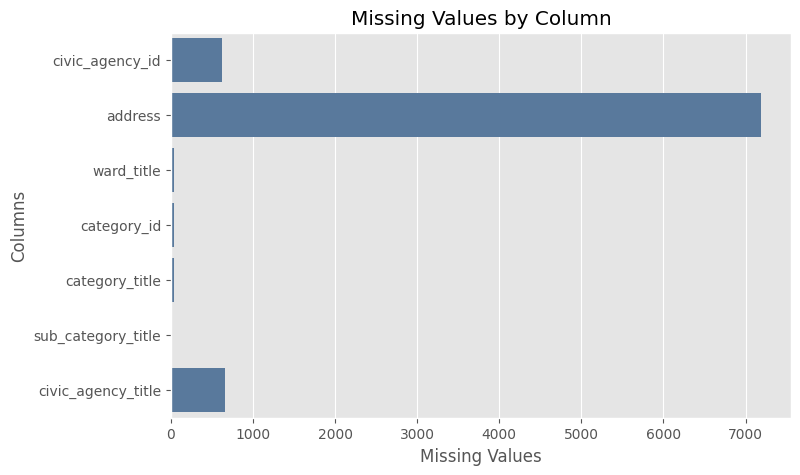

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=missing_values['Missing Values'],
    y=missing_values.index,
    color='#4E79A7'
)

plt.title('Missing Values by Column')
plt.xlabel('Missing Values')
plt.ylabel('Columns')

plt.show()


The dataset is largely complete. Most missing values are concentrated in the `address` column, while the remaining variables contain only a small number of missing records.

## Duplicate Records

The dataset is checked for duplicate observations to ensure that each complaint is represented only once.

In [10]:
issues.duplicated().sum()

np.int64(0)

No duplicate records were identified in the dataset, indicating that each complaint is represented by a unique record.

---

# 5. Feature Engineering

The `created_at` column is converted to datetime format, and additional temporal features are extracted to support trend analysis.

In [11]:
issues['created_at'] = pd.to_datetime(
    issues['created_at'],
    format='mixed',
    dayfirst=True
)

issues['year'] = issues['created_at'].dt.year

issues['month_name'] = issues['created_at'].dt.month_name()

---
# 6. Complaint Analysis

This section examines the overall distribution of complaints to identify the categories contributing the highest number of reported civic issues.

### 6.1 Category-Level Analysis

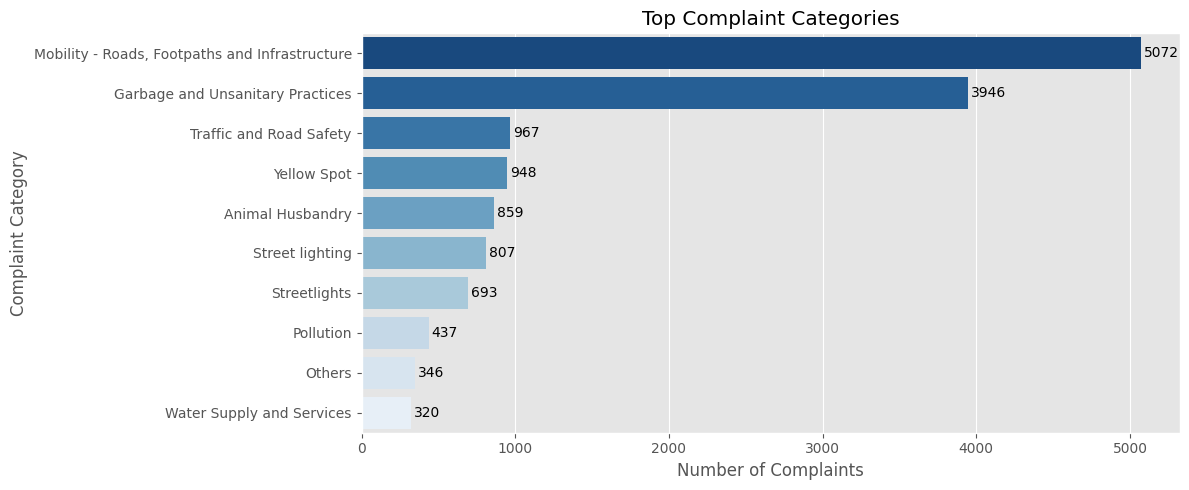

In [12]:
category_counts = (
    issues['category_title']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index,
    palette='Blues_r'
)
for i, value in enumerate(category_counts.values):
    plt.text(value + 20,i,str(value),va='center',fontsize=10)

plt.title('Top Complaint Categories')
plt.xlabel('Number of Complaints')
plt.ylabel('Complaint Category')

plt.tight_layout()
plt.show()

Road infrastructure and sanitation-related issues dominate citizen complaints, together accounting for a substantial share of all reported cases.

### 6.2 Issue-Level Analysis

This analysis identifies the most frequently reported complaint types, providing a more detailed understanding of the recurring civic issues reported by citizens.

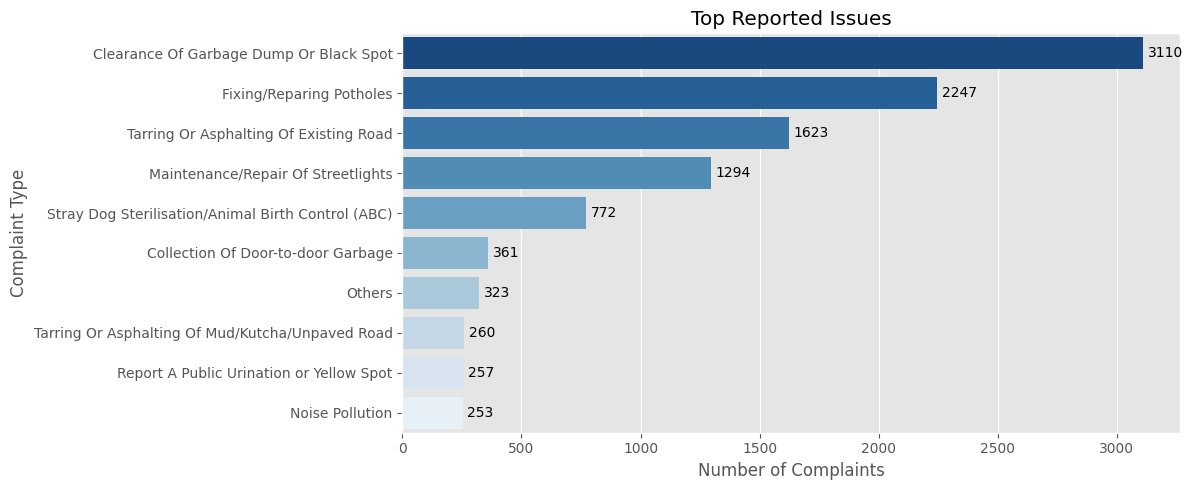

In [13]:
subcategory_counts = (
    issues['sub_category_title']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=subcategory_counts.values,
    y=subcategory_counts.index,
    palette='Blues_r'
)

# Add complaint count labels
for i, value in enumerate(subcategory_counts.values):
    plt.text(
        value + 20,
        i,
        str(value),
        va='center',
        fontsize=10
    )

plt.title('Top Reported Issues')
plt.xlabel('Number of Complaints')
plt.ylabel('Complaint Type')

plt.tight_layout()
plt.show()

Recurring complaint types are concentrated around a few service issues, suggesting opportunities for targeted operational improvements.

---
# 7. Complaint Status Analysis

This section examines the distribution of complaint statuses to understand the overall progress of issue resolution and identify the proportion of complaints in different stages of the service lifecycle.

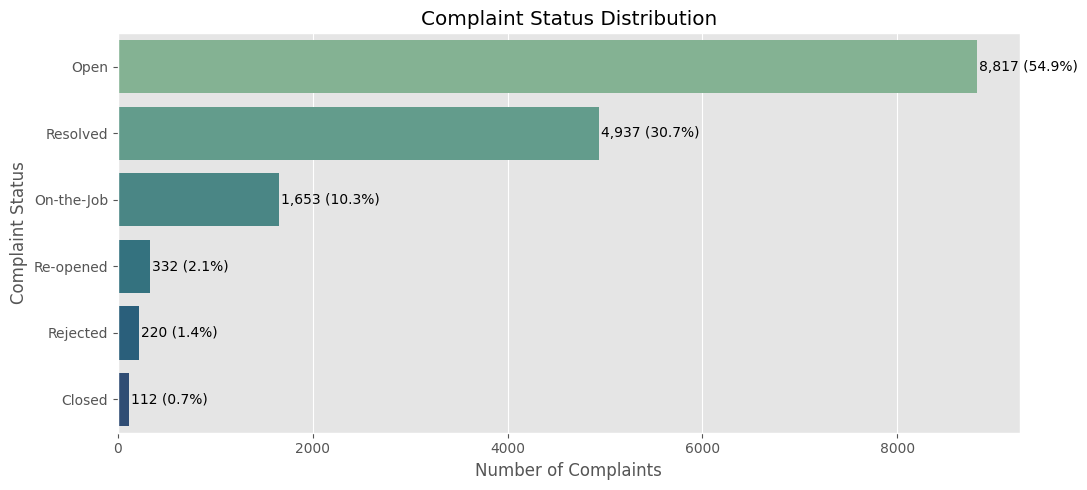

In [14]:
status_counts = (
    issues['complaint_status_title']
    .value_counts()
)

plt.figure(figsize=(11,5))

sns.barplot(
    x=status_counts.values,
    y=status_counts.index,
    palette='crest'
)

total = status_counts.sum()

for i, value in enumerate(status_counts.values):
    pct = (value / total) * 100

    plt.text(
        value + 20,
        i,
        f'{value:,} ({pct:.1f}%)',
        va='center',
        fontsize=10
    )

plt.title('Complaint Status Distribution')
plt.xlabel('Number of Complaints')
plt.ylabel('Complaint Status')

plt.tight_layout()
plt.show()

More than half of all complaints **(54.9%)** remain in the Open status, while **30.7%** have been Resolved. The remaining complaints are distributed across On-the-Job **(10.3%)**, Re-opened **(2.1%)**, Rejected **(1.4%)**, and Closed **(0.7%)**, providing an overview of the municipality's current complaint handling workflow.

---
# 8. Civic Agency Analysis

This section analyzes complaint volumes across civic agencies to identify departments receiving the highest number of citizen complaints.

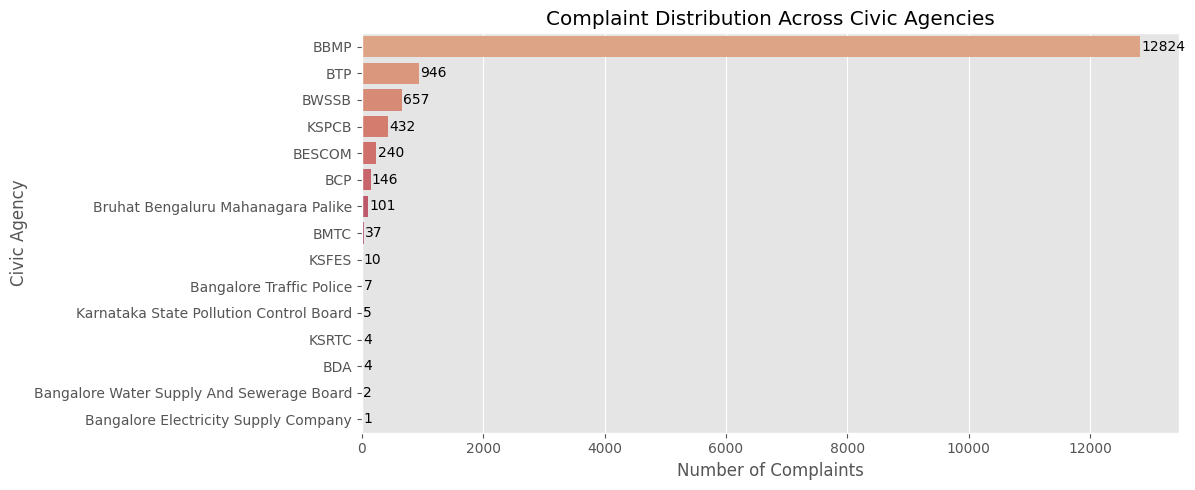

In [15]:
agency_counts = (
    issues['civic_agency_title']
    .value_counts()
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=agency_counts.values,
    y=agency_counts.index,
    palette='flare'
)

# Add count labels
for i, value in enumerate(agency_counts.values):
    plt.text(
        value + 20,
        i,
        str(value),
        va='center',
        fontsize=10
    )

plt.title('Complaint Distribution Across Civic Agencies')
plt.xlabel('Number of Complaints')
plt.ylabel('Civic Agency')

plt.tight_layout()
plt.show()

The distribution of complaints is highly skewed toward BBMP, reflecting its central role in handling municipal service requests. Other civic agencies account for only a small proportion of the overall complaint volume.

---
# 9. Ward Analysis

This section identifies the wards reporting the highest number of complaints, helping highlight geographical areas that may require greater municipal attention and resource allocation.

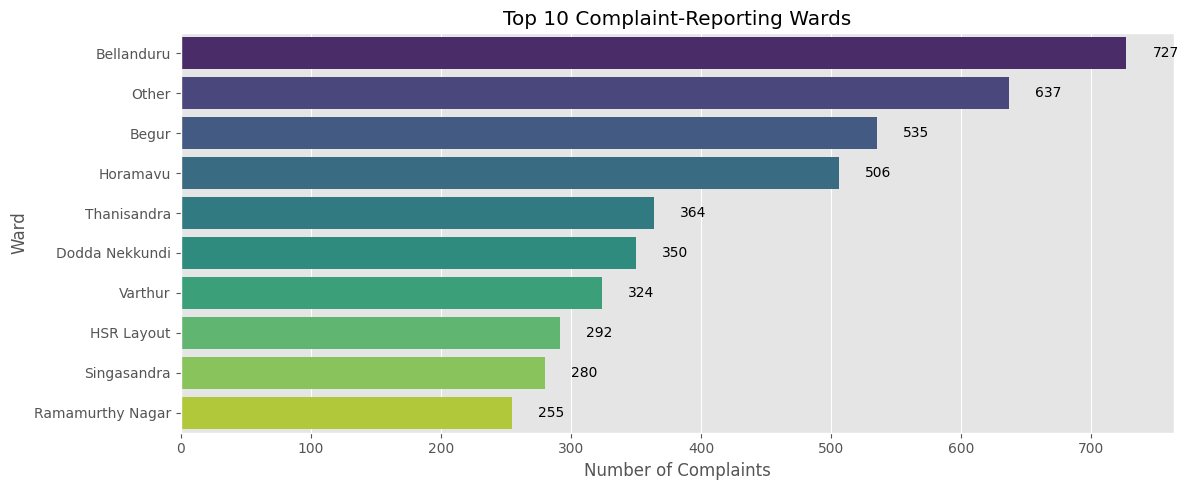

In [16]:
ward_counts = (
    issues['ward_title']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=ward_counts.values,
    y=ward_counts.index,
    palette='viridis'
)

# Add complaint count labels
for i, value in enumerate(ward_counts.values):
    plt.text(
        value + 20,
        i,
        str(value),
        va='center',
        fontsize=10
    )

plt.title('Top 10 Complaint-Reporting Wards')
plt.xlabel('Number of Complaints')
plt.ylabel('Ward')

plt.tight_layout()
plt.show()

Complaint reporting is concentrated among the top 10 wards, indicating localized areas with higher demand for municipal services. These wards represent priority locations for focused planning and resource allocation.

---
# 10. Complaint Trend Analysis

This section analyzes annual complaint volumes to identify changes in complaint reporting patterns across the study period.

### Complaint Volume by Year

This visualization compares the total number of complaints reported each year, providing an overview of how complaint volumes have evolved over time.

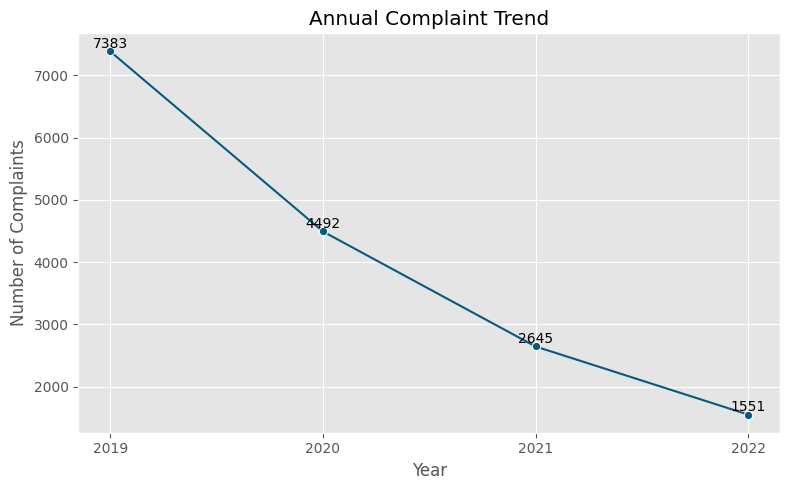

In [17]:
year_counts = (
    issues['year']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

sns.lineplot(
    x=year_counts.index.astype(str),
    y=year_counts.values,
    color="#065A82",
    marker='o'
)

# Add value labels
for i, value in enumerate(year_counts.values):
    plt.text(
        i,
        value + 50,
        str(value),
        ha='center',
        fontsize=10
    )

plt.title('Annual Complaint Trend')
plt.xlabel('Year')
plt.ylabel('Number of Complaints')

plt.tight_layout()
plt.show()

Complaint volumes declined from 7,383 in 2019 to 1,551 in 2022 — a 79% drop over four years. The sharpest single-year decline occurred between 2019 and 2020, coinciding with the COVID-19 pandemic and associated lockdowns that significantly reduced citizen mobility and platform engagement. Beyond 2020, the continued decline may reflect improvements in municipal service delivery, reduced citizen engagement with the platform, or partial data capture for later years — as the dataset may have been exported before all records were fully updated.

---
# 11. Key Insights

* Road infrastructure and sanitation-related issues account for a significant share of reported complaints, highlighting key areas requiring continued municipal attention.
* Complaint reporting is concentrated within a limited number of civic agencies and wards, highlighting localized service demand and opportunities for targeted resource allocation.
* The complaint management process is largely represented by completed and active cases, providing an overview of the municipality's service response workflow.
* Complaint volumes declined 79% from 7,383 in 2019 to 1,551 in 2022. The steepest drop occurred in 2020, likely driven by COVID-19 lockdowns reducing citizen mobility and reporting activity. The continued decline post-2020 may reflect service improvements, lower platform engagement, or incomplete data capture for later years.
* Overall, the analysis demonstrates how complaint data can support evidence-based decision-making by helping identify operational priorities, improve resource planning, and enhance municipal service delivery.


---
# 12. Conclusion

This exploratory data analysis examined 16,071 citizen-reported complaints submitted to the Bengaluru Municipality between 2019 and 2022. The analysis identified that complaint activity is primarily concentrated within a limited number of categories, civic agencies, and wards, highlighting key areas for municipal planning and resource allocation.

Complaint volumes declined 79% over the study period — from 7,383 in 2019 to 1,551 in 2022. The sharpest drop occurred in 2020, coinciding with COVID-19 lockdowns that reduced citizen mobility and platform engagement. While the post-2020 decline may reflect service improvements or reduced platform usage, data completeness for later years cannot be fully confirmed. Overall, the analysis demonstrates how complaint data can support evidence-based planning and operational decision-making.
